In [2]:
import pandas as pd
import numpy as np

In [17]:
data = pd.read_csv("data/eda_data.csv")
data.head()

,SWANID,AGE,RACE(1) Black/African American,RACE(2) Chinese/Chinese American,RACE(3) Japanese/Japanese American,DEGREE,DIABETE0,PHYSACT0,MARITAL0,HEIGHT0,...,SMOKERE10,DRNKBEE10,DEPRESSION10,ANXIETY10,D_HORMUSER10,HORMUSER10,C_SPBMDT10,SPBMDT10,C_HPBMDT10,HPBMDT10
0,10046,52,0,1,0,1,0,4,1,156.0,...,0.0,0.0,16.0,0.0,0,1.0,0,1.163358,0,1.034961
1,10056,51,0,0,0,2,0,2,1,161.7,...,0.0,1.0,12.0,0.0,0,0.0,0,0.894210,0,0.847180
2,10092,45,0,0,0,2,0,2,1,167.1,...,NaN,NaN,NaN,NaN,1,NaN,1,NaN,1,NaN
3,10153,51,0,0,1,1,0,3,1,149.4,...,0.0,0.0,12.0,2.0,0,0.0,0,1.007640,0,0.983010
4,10196,46,0,1,0,4,0,2,1,153.4,...,0.0,0.0,14.0,3.0,0,0.0,0,0.831566,0,0.767219


In [18]:
data.shape

(1804, 190)

# Check NaNs

In [19]:
data.isna().sum().sort_values(ascending=False)

PHYSACT10      1804
PHYSACT4       1804
DRNKBEE5       1804
PHYSACT7       1804
PHYSACT8       1804
               ... 
HORMUSER1         0
D_HORMUSER8       0
D_HORMUSER1       0
C_SPBMDT8         0
SWANID            0
Length: 190, dtype: int64

<AxesSubplot:>

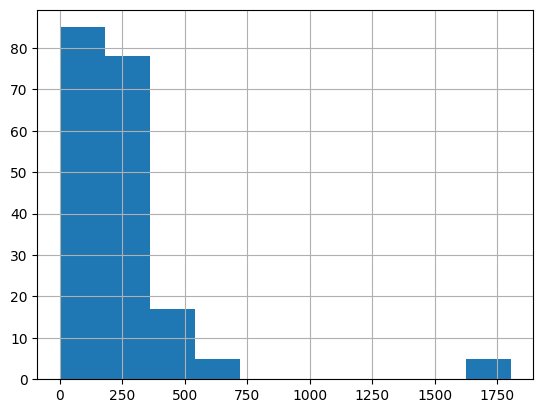

In [20]:
# number of nulls in each column; there seems to be a lot of columns with under 700 nulls,
# and then a group of columns with 1,804 nulls, which makes sense because these are the covariates in certain visits
# that did not exist (so they are just a column of nulls)
data.isna().sum().hist()

In [21]:
data.isna().sum().sort_values(ascending=False)[5:]

DEPRESSION8    696
DRNKBEE8       695
HPBMDT8        658
SPBMDT8        654
HEIGHT8        628
              ... 
HORMUSER1        0
D_HORMUSER8      0
D_HORMUSER1      0
C_SPBMDT8        0
SWANID           0
Length: 185, dtype: int64

We can see that the nulls in the outcomes (HPBMDT, SPBMDT) increase starting at visit 4. From there, it's generally increasing per visit, except for visits 8-10, where the most nulls occur at visit 8, then visit 9, then visit 10. Then, exposure HORMUSER10 is the next most missing. We can also see that HPBMDT and SPBMDT do not have the same amount of nulls per visit. It's kind of random which ones had more nulls than the other: more nulls in HPBMDT for visits 2, 6, 7, 8, 9, 10; more nulls in SPBMDT for visits 1, 3, 4, 5.

Also, all HORMUSER's are below the HPBMDT, SPBMDT for each visit. This means, there are more individuals with unknown outcome than unknown exposure at each visit. We now investigate whether this is true for all individuals. 

## Check NaN discrepancy between exposure and outcome.
Do we need to separate censoring for exposure and outcome?

In [26]:
# columns with at least one null
short_col = data.columns[data.isnull().any(axis=0)].tolist()[2:]

In [27]:
# Among those with at least one null, how many had a null exposure but not null outcome, and vice versa for each visit?

# 1,804 out of 1,804 rows have at least one null
data_w_null = data[data.isnull().any(axis=1)][short_col]
data_w_null.shape

(1804, 136)

In [28]:
data_w_null

,MARITAL1,HEIGHT1,WEIGHT1,STATUS1,SMOKERE1,DRNKBEE1,DEPRESSION1,ANXIETY1,SPBMDT1,HPBMDT1,...,WEIGHT10,STATUS10,INSULIN10,SMOKERE10,DRNKBEE10,DEPRESSION10,ANXIETY10,HORMUSER10,SPBMDT10,HPBMDT10
0,1.0,155.4,74.0,6.0,0.0,0.0,17.0,1.0,1.1277,0.9619,...,89.4,6.0,0.0,0.0,0.0,16.0,0.0,1.0,1.163358,1.034961
1,1.0,161.3,53.2,3.0,0.0,1.0,16.0,1.0,0.9140,0.8499,...,53.4,1.0,0.0,0.0,1.0,12.0,0.0,0.0,0.894210,0.847180
2,1.0,166.1,85.6,3.0,0.0,1.0,13.0,1.0,1.0377,0.8412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,149.5,68.0,3.0,0.0,0.0,13.0,1.0,1.0673,1.0313,...,69.6,1.0,0.0,0.0,0.0,12.0,2.0,0.0,1.007640,0.983010
4,1.0,153.6,49.1,3.0,0.0,0.0,12.0,0.0,0.9806,0.7968,...,53.2,1.0,0.0,0.0,0.0,14.0,3.0,0.0,0.831566,0.767219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,1.0,158.6,81.8,3.0,0.0,1.0,17.0,1.0,NaN,NaN,...,86.7,0.0,0.0,0.0,1.0,17.0,2.0,0.0,NaN,NaN
1800,1.0,161.4,78.3,6.0,0.0,1.0,14.0,2.0,1.1747,1.0018,...,81.5,3.0,0.0,0.0,1.0,17.0,2.0,0.0,1.199120,0.999020
1801,2.0,166.0,84.8,3.0,1.0,1.0,19.0,4.0,1.1394,1.0013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,1.0,159.0,73.6,6.0,1.0,0.0,44.0,6.0,1.0116,0.9056,...,67.2,1.0,0.0,1.0,0.0,42.0,15.0,1.0,0.910560,0.763750


In [31]:
# visit 1
# HORMUSER1: 0 (does not show up in short_col)
# SPBMDT1: 75
# HPBMDT1: 71
data_w_null[['SPBMDT1', 'HPBMDT1']].isna().sum()

SPBMDT1    75
HPBMDT1    71
dtype: int64

In [34]:
# visit 2
# HORMUSER2: 105
# SPBMDT2: 185
# HPBMDT2: 187
visit2 = data_w_null.loc[:, ['HORMUSER2', 'SPBMDT2', 'HPBMDT2']]
visit2.isna().sum()

HORMUSER2    105
SPBMDT2      185
HPBMDT2      187
dtype: int64

In [36]:
# visit 2: 1 individual with null exposure, but at least one measured outcome
visit2_temp = visit2[visit2['HORMUSER2'].isna()].notna()
visit2_temp[visit2_temp['SPBMDT2'] | visit2_temp['HPBMDT2']]

,HORMUSER2,SPBMDT2,HPBMDT2
168,False,True,True


In [39]:
# visit 2: 81 individuals with measured exposure, null SPBMDT2
# visit 2: 5 individuals with measured HPBMDT2, null SPBMDT2 (all 5 of these also had measured exposure)
visit2[visit2['SPBMDT2'].isna()].notna().sum()

HORMUSER2    81
SPBMDT2       0
HPBMDT2       5
dtype: int64

In [44]:
visit2[visit2['SPBMDT2'].isna()].notna()[['HORMUSER2', 'HPBMDT2']].sort_values(by='HPBMDT2', ascending=False)

,HORMUSER2,HPBMDT2
900,True,True
1569,True,True
804,True,True
785,True,True
270,True,True
...,...,...
585,False,False
587,False,False
618,True,False
623,False,False


In [45]:
# visit 2: 83 individuals with measured exposure, null HPBMDT2
# visit 2: 7 individuals with measured SPBMDT2, null HPBMDT2 (all 7 of these also had measured exposure)
visit2[visit2['HPBMDT2'].isna()].notna().sum()

HORMUSER2    83
SPBMDT2       7
HPBMDT2       0
dtype: int64

In [49]:
visit2[visit2['HPBMDT2'].isna()].notna()[['HORMUSER2', 'SPBMDT2']].sort_values(by='SPBMDT2', ascending=False)

,HORMUSER2,SPBMDT2
1258,True,True
17,True,True
323,True,True
1726,True,True
1024,True,True
...,...,...
587,False,False
618,True,False
623,False,False
633,True,False


In [46]:
# visit 2: 76 individuals with measured exposure, null SPBMDT2 & HPBMDT2
visit2[visit2['SPBMDT2'].isna() & visit2['HPBMDT2'].isna()].notna().sum()

HORMUSER2    76
SPBMDT2       0
HPBMDT2       0
dtype: int64

In [47]:
# visit 2: 88 individuals with measured exposure, null SPBMDT2 or HPBMDT2
visit2[visit2['SPBMDT2'].isna() | visit2['HPBMDT2'].isna()].notna().sum()

HORMUSER2    88
SPBMDT2       7
HPBMDT2       5
dtype: int64

In [50]:
# for each visit, how many individuals with null exposure, but measured outcome? 
visit_prefix = ['HORMUSER', 'SPBMDT', 'HPBMDT'] 
throw_away_index = []
for i in range(2, 11):
    visit_i_col = [prefix + str(i) for prefix in visit_prefix]
    visit_i = data_w_null[visit_i_col]
    visit_i_temp = visit_i[visit_i[visit_i_col[0]].isna()].notna()
    visit_i_unique_nulls = visit_i_temp[visit_i_temp[visit_i_col[1]] | visit_i_temp[visit_i_col[2]]]
    print('NULL EXPOSURE, MEASURED OUTCOME')
    print(visit_i_temp.sum())
    print(str(visit_i_unique_nulls.shape[0]) + ' unique individuals')
    print(visit_i_unique_nulls.index)
    throw_away_index.append(visit_i_unique_nulls.index.tolist())
    # print('MEASURED EXPOSURE, NULL SPBMDT')
    # print(visit_i[visit_i[visit_i_col[1]].isna()].notna().sum())
    # print('MEASURED EXPOSURE, NULL HPBMDT')
    # print(visit_i[visit_i[visit_i_col[2]].isna()].notna().sum())
    print('---------------')

NULL EXPOSURE, MEASURED OUTCOME
HORMUSER2    0
SPBMDT2      1
HPBMDT2      1
dtype: int64
1 unique individuals
Int64Index([168], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER3    0
SPBMDT3      0
HPBMDT3      0
dtype: int64
0 unique individuals
Int64Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER4    0
SPBMDT4      0
HPBMDT4      0
dtype: int64
0 unique individuals
Int64Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER5    0
SPBMDT5      0
HPBMDT5      0
dtype: int64
0 unique individuals
Int64Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER6    0
SPBMDT6      0
HPBMDT6      0
dtype: int64
0 unique individuals
Int64Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER7    0
SPBMDT7      1
HPBMDT7      1
dtype: int64
1 unique individuals
Int64Index([1288], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER8    0
SPBM

In [51]:
data.iloc[sorted(sum(throw_away_index, []))]['SWANID']

168     18363
1288    73133
1445    81044
1656    91466
1784    98865
Name: SWANID, dtype: int64

**Conclusion**: Remove the 5 individuals that have null exposure but measured outcome. We now only have one censoring variable that is defined by outcome. It is still okay that there is censoring discrepancy between the two outcomes, because we are only looking at one outcome at a time. We can just do LVCF for the other outcome that is now treated as an intermediate covariate, if it is null. 

In [52]:
data_no_null_hormuser = data.iloc[data.index.difference(sorted(sum(throw_away_index, [])))]
data_no_null_hormuser.shape

(1799, 190)

In [54]:
# let's also just check how much we are throwing away; i.e. amount of nulls in these five individuals
data.iloc[sorted(sum(throw_away_index, []))].isna().sum().sort_values(ascending=False)

DEPRESSION8    5
PHYSACT10      5
DRNKBEE5       5
PHYSACT7       5
DRNKBEE8       5
              ..
C_HPBMDT3      0
HPBMDT3        0
DIABETE4       0
MARITAL4       0
SMOKERE5       0
Length: 190, dtype: int64

I think it's fine to remove these five; they do have quite a bit of measured outcome (pretty much all visits except 1, 8, 9, and 10). But, the women with unknown exposure is just one for visits 2 and 7 each, and three for visit 8. So, not really huge wrt sample size.

## NaN Summaries
Good to know wrt sample size.
1. How many censored at each visit?
2. How many truly LTFU? At what visit? 
3. How many came back? At what visit? i.e. not truly LTFU
4. How many had no censoring at all?

In [56]:
# remember: we can just look at the nulls in SPBMDT and HPBMDT
censor_prefix = ['SPBMDT', 'HPBMDT'] 
censor_col = [prefix + str(i) for i in range(0, 11) for prefix in censor_prefix]
data_censor = data[censor_col]
data_censor

,SPBMDT0,HPBMDT0,SPBMDT1,HPBMDT1,SPBMDT2,HPBMDT2,SPBMDT3,HPBMDT3,SPBMDT4,HPBMDT4,...,SPBMDT6,HPBMDT6,SPBMDT7,HPBMDT7,SPBMDT8,HPBMDT8,SPBMDT9,HPBMDT9,SPBMDT10,HPBMDT10
0,1.1163,0.9280,1.1277,0.9619,1.134700,0.976400,1.185100,0.991600,1.17200,0.999300,...,1.160900,0.989100,1.24091,1.013800,1.169714,1.018032,1.180962,0.995748,1.163358,1.034961
1,0.8954,0.8547,0.9140,0.8499,0.893400,0.840700,0.872400,0.836800,0.85470,0.829500,...,0.874200,0.830500,0.88456,0.849060,NaN,NaN,0.913260,0.868260,0.894210,0.847180
2,1.0471,0.8158,1.0377,0.8412,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0729,1.0469,1.0673,1.0313,1.047900,1.023800,1.018300,1.024500,1.00950,0.971800,...,1.023300,1.036000,1.06053,1.025610,1.042200,1.023820,1.002990,0.985670,1.007640,0.983010
4,0.9888,0.8047,0.9806,0.7968,0.974400,0.784100,0.955600,0.788100,NaN,0.775500,...,0.906900,0.772300,0.88690,0.763300,NaN,NaN,0.850951,0.754536,0.831566,0.767219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,1.2031,1.3088,NaN,NaN,1.253886,1.377238,1.195363,1.353982,NaN,NaN,...,1.060038,1.208606,NaN,NaN,NaN,NaN,1.007260,1.197130,NaN,NaN
1800,1.1201,1.0073,1.1747,1.0018,1.170600,1.008700,1.133900,1.011778,1.11927,1.007264,...,1.144373,1.007653,1.13548,1.019292,1.164150,1.018430,1.158630,1.004950,1.199120,0.999020
1801,1.1642,1.0050,1.1394,1.0013,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,1.0659,0.9026,1.0116,0.9056,1.027800,0.875900,1.036800,0.851400,0.93860,0.874300,...,1.039900,0.832700,0.99519,0.813460,0.984180,0.828910,0.960860,0.821580,0.910560,0.763750


In [57]:
# 1. proportion of nulls per visit; in order of visit
data_censor.isna().mean()

SPBMDT0     0.000000
HPBMDT0     0.000000
SPBMDT1     0.041574
HPBMDT1     0.039357
SPBMDT2     0.102550
HPBMDT2     0.103659
SPBMDT3     0.152439
HPBMDT3     0.148004
SPBMDT4     0.186807
HPBMDT4     0.184035
SPBMDT5     0.199557
HPBMDT5     0.196785
SPBMDT6     0.210643
HPBMDT6     0.211752
SPBMDT7     0.233925
HPBMDT7     0.235588
SPBMDT8     0.362528
HPBMDT8     0.364745
SPBMDT9     0.278825
HPBMDT9     0.279379
SPBMDT10    0.270510
HPBMDT10    0.272727
dtype: float64

In [59]:
# 1. proportion of nulls per visit; in order of number of nulls
data_censor.isna().mean().sort_values()

SPBMDT0     0.000000
HPBMDT0     0.000000
HPBMDT1     0.039357
SPBMDT1     0.041574
SPBMDT2     0.102550
HPBMDT2     0.103659
HPBMDT3     0.148004
SPBMDT3     0.152439
HPBMDT4     0.184035
SPBMDT4     0.186807
HPBMDT5     0.196785
SPBMDT5     0.199557
SPBMDT6     0.210643
HPBMDT6     0.211752
SPBMDT7     0.233925
HPBMDT7     0.235588
SPBMDT10    0.270510
HPBMDT10    0.272727
SPBMDT9     0.278825
HPBMDT9     0.279379
SPBMDT8     0.362528
HPBMDT8     0.364745
dtype: float64

In [60]:
# now we need to separate between SPBMDT and HPBMDT
data_censor_s = data_censor[['SPBMDT' + str(i) for i in range(0, 11)]]
data_censor_h = data_censor[['HPBMDT' + str(i) for i in range(0, 11)]]

- e.g., rows 2, 1879, 1881 is truly LTFU
    - rows 2, 1881 LTFU at visit 2
    - row 1879 LTFU at visit 10, but has values in between
- e.g., rows 1, 4, 1883 have censored values, but not truly LTFU

In [61]:
# 2. for each visit, how many were truly LTFU and at which visit? SPBMDT
# get the last column that is not null for each person
# row 1: 10
# row 2: 1
# row 1879: 9
u = data_censor_s.notna().iloc[:,::-1].cumsum(axis=1)
u.eq(1).dot(u.columns+',').str.split(',').str[0].value_counts()

SPBMDT10    1316
SPBMDT9       95
SPBMDT1       61
SPBMDT4       54
SPBMDT7       52
SPBMDT8       51
SPBMDT2       48
SPBMDT3       41
SPBMDT6       41
SPBMDT5       33
SPBMDT0       12
dtype: int64

Conclusion: 1,316 out of 1,804 individuals were not truly LTFU (but, they may still have null outcome at some visits in between baseline and visit 10).

In [62]:
# 2. for each visit, how many were truly LTFU and at which visit? HPBMDT
v = data_censor_h.notna().iloc[:,::-1].cumsum(axis=1)
v.eq(1).dot(v.columns+',').str.split(',').str[0].value_counts()

HPBMDT10    1312
HPBMDT9       95
HPBMDT1       61
HPBMDT7       53
HPBMDT8       53
HPBMDT4       53
HPBMDT2       47
HPBMDT3       41
HPBMDT6       40
HPBMDT5       37
HPBMDT0       12
dtype: int64

Conclusion: 1,312 out of 1,804 individuals were not truly LTFU. The numbers are similar to the SPBMDT ones, maybe off by one or two.

In [63]:
# 3. among the 1,316 SPBMDT10 not truly LTFU, how many had null visits in between? at which visits?
data_censor_s_not_LTFU = data_censor_s[data_censor_s['SPBMDT10'].notna()]
data_censor_s_not_LTFU.isna().sum()

SPBMDT0       0
SPBMDT1      35
SPBMDT2      67
SPBMDT3      93
SPBMDT4     105
SPBMDT5      89
SPBMDT6      87
SPBMDT7      96
SPBMDT8     277
SPBMDT9     110
SPBMDT10      0
dtype: int64

Conclusion: 35 nulls at visit 1, 67 nulls at visit 2, etc. Again, we see the most nulls at 277 nulls at visit 8.

In [66]:
# 3. among the 1,316 SPBMDT10 not truly LTFU, how many null visits did they have in between?
data_censor_s_not_LTFU.isna().sum(axis=1).value_counts().sort_index(ascending=False)

8      1
7      4
6      9
5     15
4     24
3     48
2    107
1    340
0    768
dtype: int64

Conclusion:
- 1 individuals had 8 null visits
- 4 individuals had 7 null visits
- ...
- 768 individuals had no null visits (yay!)

In [67]:
# let's look into the individuals with many null visits; which visits were they measured? 
data_censor_s_not_LTFU[data_censor_s_not_LTFU.isna().sum(axis=1) >= 7]

,SPBMDT0,SPBMDT1,SPBMDT2,SPBMDT3,SPBMDT4,SPBMDT5,SPBMDT6,SPBMDT7,SPBMDT8,SPBMDT9,SPBMDT10
206,0.8366,0.862900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.826828
279,1.2341,1.260500,NaN,1.2164,NaN,NaN,NaN,NaN,NaN,NaN,1.092060
1201,0.9784,0.964700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87203,0.871610
1583,1.0302,1.024430,NaN,NaN,NaN,NaN,0.93806,NaN,NaN,NaN,0.928670
1645,1.1963,1.234461,1.160298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.075740


Conclusion:
- for the one individual with 8 nulls:
    - row 206: 1
- for the four individuals with 7 nulls:
    - row 279: 1, 3
    - row 1201: 1, 9
    - row 1583: 1, 6
    - row 1645: 1, 2

In [68]:
# let's look into the individuals with few null visits; which visits were null?
data_censor_s_not_LTFU[data_censor_s_not_LTFU.isna().sum(axis=1) == 1].isna().sum()

SPBMDT0       0
SPBMDT1      15
SPBMDT2      25
SPBMDT3      21
SPBMDT4      31
SPBMDT5      15
SPBMDT6      17
SPBMDT7      21
SPBMDT8     170
SPBMDT9      25
SPBMDT10      0
dtype: int64

Conclusion:
- visit 8 had the most nulls, with 170 nulls
- all other visits had somewhere between 15 to 31 nulls

In [70]:
# 3. among the 1,312 HPBMDT10 not truly LTFU, how many had null visits in between? at which visits?
data_censor_h_not_LTFU = data_censor_h[data_censor_h['HPBMDT10'].notna()]
data_censor_h_not_LTFU.isna().sum()

HPBMDT0       0
HPBMDT1      33
HPBMDT2      70
HPBMDT3      89
HPBMDT4     102
HPBMDT5      89
HPBMDT6      86
HPBMDT7      99
HPBMDT8     276
HPBMDT9     107
HPBMDT10      0
dtype: int64

Conclusion: 33 nulls at visit 1, 70 nulls at visit 2, etc. Again, we see the most nulls at 276 nulls at visit 8.

In [72]:
# 3. among the 1,312 HPBMDT10 not truly LTFU, how many null visits did they have in between?
data_censor_h_not_LTFU.isna().sum(axis=1).value_counts().sort_index(ascending=False)

8      1
7      4
6      8
5     16
4     23
3     47
2    105
1    344
0    764
dtype: int64

Conclusion:
- 1 individuals had 8 null visits
- 4 individuals had 7 null visits
- ...
- 764 individuals had no null visits (yay!)

In [73]:
# let's look into the individuals with many null visits; which visits were they measured? 
data_censor_h_not_LTFU[data_censor_h_not_LTFU.isna().sum(axis=1) >= 7]

,HPBMDT0,HPBMDT1,HPBMDT2,HPBMDT3,HPBMDT4,HPBMDT5,HPBMDT6,HPBMDT7,HPBMDT8,HPBMDT9,HPBMDT10
206,0.7961,0.810700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.862844
279,0.9679,0.966000,NaN,0.9639,NaN,NaN,NaN,NaN,NaN,NaN,0.876770
1201,0.8396,0.823200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.77446,0.788630
1583,0.8477,0.851697,NaN,NaN,NaN,NaN,0.79841,NaN,NaN,NaN,0.784160
1645,1.1331,1.061307,1.125013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.061870


These are the same individuals as the SPBMDT ones.

In [76]:
# let's look into the individuals with few null visits; which visits were null?
data_censor_h_not_LTFU[data_censor_h_not_LTFU.isna().sum(axis=1) == 1].isna().sum()

HPBMDT0       0
HPBMDT1      14
HPBMDT2      29
HPBMDT3      19
HPBMDT4      28
HPBMDT5      14
HPBMDT6      19
HPBMDT7      24
HPBMDT8     172
HPBMDT9      25
HPBMDT10      0
dtype: int64

Conclusion:
- visit 8 had the most null, with 172 nulls
- all other visits had somewhere between 14 to 29 nulls

In [79]:
# 4. how many had no censoring at all? 742 women
data_censor.dropna()

,SPBMDT0,HPBMDT0,SPBMDT1,HPBMDT1,SPBMDT2,HPBMDT2,SPBMDT3,HPBMDT3,SPBMDT4,HPBMDT4,...,SPBMDT6,HPBMDT6,SPBMDT7,HPBMDT7,SPBMDT8,HPBMDT8,SPBMDT9,HPBMDT9,SPBMDT10,HPBMDT10
0,1.116300,0.9280,1.127700,0.961900,1.134700,0.976400,1.185100,0.991600,1.172000,0.999300,...,1.160900,0.989100,1.240910,1.013800,1.169714,1.018032,1.180962,0.995748,1.163358,1.034961
3,1.072900,1.0469,1.067300,1.031300,1.047900,1.023800,1.018300,1.024500,1.009500,0.971800,...,1.023300,1.036000,1.060530,1.025610,1.042200,1.023820,1.002990,0.985670,1.007640,0.983010
5,1.047300,0.9667,1.024000,0.966600,0.996204,0.949455,0.957200,0.958300,0.950000,0.941100,...,0.918600,0.978300,0.918990,0.998150,0.850830,0.925370,0.814220,0.873880,0.800160,0.827300
8,1.042300,1.0793,1.009754,1.092234,1.034009,1.079631,1.010600,1.074400,1.001700,1.061000,...,1.019040,1.091330,1.036240,1.091040,1.061130,1.118640,1.037010,1.125770,1.024750,1.113560
9,1.057400,0.8509,1.042400,0.842500,1.045700,0.882400,1.047000,0.873300,1.043800,0.879200,...,1.052700,0.882100,1.014300,0.881700,0.967609,0.869306,0.975198,0.866071,0.942157,0.832346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,0.975800,0.8717,0.969800,0.877100,0.990500,0.868500,0.946662,0.869105,0.958079,0.875372,...,0.958379,0.891680,0.937797,0.864211,0.924310,0.874890,0.921810,0.882660,0.881220,0.878880
1796,0.862000,0.6525,0.876000,0.669100,0.897600,0.689800,0.876500,0.667600,0.830200,0.678900,...,0.871200,0.684300,0.867200,0.711100,0.836198,0.690419,0.892977,0.713127,0.857837,0.691527
1797,1.197879,0.9320,1.212749,0.926900,1.206403,0.946500,1.192167,0.923171,1.182600,0.910922,...,1.141298,0.929570,1.132058,0.910136,1.124380,0.902950,1.105962,0.889960,1.104759,0.900500
1800,1.120100,1.0073,1.174700,1.001800,1.170600,1.008700,1.133900,1.011778,1.119270,1.007264,...,1.144373,1.007653,1.135480,1.019292,1.164150,1.018430,1.158630,1.004950,1.199120,0.999020


# Check positivity

In [116]:
# data_no_null_hormuser is the dataframe from data where we removed the five individuals with null exposure but measured outcome
# there are still nulls in the hormuser columns
hormuser = ['HORMUSER' + str(i) for i in range(0, 11)]
data_no_null_hormuser[hormuser]

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
0,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1799,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1800,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1801,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,0,1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


Yikes. We have quite imbalanced exposed/not exposed groups. 

In [125]:
test = pd.melt(data[hormuser]).reset_index().groupby(['value', 'variable']).count().reset_index()
test_counts = pd.pivot_table(test, values='index', index='value', columns='variable', aggfunc='sum')
test_counts.loc['Total'] = test_counts.sum()
test_counts['HORMUSER10'] = test_counts.pop('HORMUSER10')
test_counts.index.names = ['No. of women']
test_counts.columns.names = ['Visit']
test_counts.reset_index(inplace=True)
test_counts.loc[:, 'No. of women'] = [0, 1, 'Total']
test_counts = test_counts.set_index('No. of women').fillna(0).astype(int)
test_counts

Visit,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
No. of women,,,,,,,,,,,
0,1804,1682,1495,1389,1314,1258,1276,1366,1374,1397,1399
1,0,122,204,260,306,338,340,216,160,133,125
Total,1804,1804,1699,1649,1620,1596,1616,1582,1534,1530,1524


In [130]:
test_counts.T[0] / test_counts.T['Total']

Visit
HORMUSER0     1.000000
HORMUSER1     0.932373
HORMUSER2     0.879929
HORMUSER3     0.842329
HORMUSER4     0.811111
HORMUSER5     0.788221
HORMUSER6     0.789604
HORMUSER7     0.863464
HORMUSER8     0.895698
HORMUSER9     0.913072
HORMUSER10    0.917979
dtype: float64

This is the number of women in either treatment = 0 or treatment = 1 at each visit. However, in L-TMLE, we run conditional expectations backwards, where we start with treatment = 0 or treatment = 1 at visit 10, then treatment = 0, 0 or treatment = 1, 1 at visit 9, and so on until visit 1 which will likely have positivity violations.

In [118]:
# how many women were never on HRTs for 10 years? exclude those with any nulls
no_null_all = data[hormuser].dropna()
no_null_all

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
0,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1798,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1799,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1800,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1802,0,1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


In [119]:
no_null_all[
    (no_null_all['HORMUSER0'] == 0) &
    (no_null_all['HORMUSER1'] == 0) &
    (no_null_all['HORMUSER2'] == 0) &
    (no_null_all['HORMUSER3'] == 0) &
    (no_null_all['HORMUSER4'] == 0) &
    (no_null_all['HORMUSER5'] == 0) &
    (no_null_all['HORMUSER6'] == 0) &
    (no_null_all['HORMUSER7'] == 0) &
    (no_null_all['HORMUSER8'] == 0) &
    (no_null_all['HORMUSER9'] == 0) &
    (no_null_all['HORMUSER10'] == 0)
    ]

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1796,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1797,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1798,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1799,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


797 women never on HRTs for 10 years

In [120]:
no_null_all[
    (no_null_all['HORMUSER0'] == 0) &
    (no_null_all['HORMUSER1'] == 1) &
    (no_null_all['HORMUSER2'] == 1) &
    (no_null_all['HORMUSER3'] == 1) &
    (no_null_all['HORMUSER4'] == 1) &
    (no_null_all['HORMUSER5'] == 1) &
    (no_null_all['HORMUSER6'] == 1) &
    (no_null_all['HORMUSER7'] == 1) &
    (no_null_all['HORMUSER8'] == 1) &
    (no_null_all['HORMUSER9'] == 1) &
    (no_null_all['HORMUSER10'] == 1)
    ]

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
0,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
30,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
366,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
529,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
906,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
939,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
975,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1039,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1341,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1360,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


12 women on HRTs continuously for 10 years

In [121]:
# at which visit do women typically start HRTs? first instance of HORMUSER = 1
data_hormuser = data[hormuser]
data_hormuser

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
0,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1799,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1800,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1801,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,0,1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


In [122]:
data_hormuser_bool = data_hormuser == 1
v = data_hormuser_bool.cumsum(axis=1)
v.eq(1).dot(v.columns+',').str.split(',').str[0].value_counts()

              1171
HORMUSER1      122
HORMUSER2      116
HORMUSER3      108
HORMUSER4       86
HORMUSER5       74
HORMUSER6       51
HORMUSER8       26
HORMUSER7       22
HORMUSER10      17
HORMUSER9       11
dtype: int64

Most women started HRT from visit 1, and this decreases with every subsequent visit. The blank row indicates never using HRTs.

In [109]:
# how long do women typically remain on HRTs? number of visits where HORMUSER = 1
v['HORMUSER10'].value_counts()

0     1167
1      174
2      112
3       85
4       69
5       58
6       55
8       26
7       24
9       17
10      12
Name: HORMUSER10, dtype: int64

Most women typically remain on HRTs for 1 visit, and this decreases with every additional visit. Note that we previously claimed that only 12 women were on HRTs for all 10 years. We see 12 women here as well, which is a good check.

In [114]:
data_hormuser.loc[v[v['HORMUSER10'] == 9].index, :]

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
83,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
181,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
202,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
405,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
426,0,1,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
587,0,1,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
818,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
864,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1257,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1270,0,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


For most of the women with 9 HRTs, they were usually consecutive (starting at visit 2 up to visit 10 and one woman starting at visit 1 up to visit 9). However, we see one woman with a null at visit 2, which we might be inclined to assume that this could be filled with a 1, but we also see one woman who started HRTs at visit 1, did not take HRTs at visit 3, then continued with HRTs until visit 10. So, hard to tell what is the right way to impute here. For simplicity, we'll just do LOCF, but there might be better ways to impute nulls.

In [85]:
# check positivity for each step in the iterated conditional expectation

In [ ]:
# check how many switch back and forth between 0 and 1 for HORMUSER

# Write different versions of data

In [169]:
# minimal changing: no shifting
# remove the other outcome in all intermediate covariates, add delta, add censoring, remove HORMUSER0, fill nas
# spine_no_shift_no_hip.csv
# hip_no_shift_no_spine.csv

spbmdt = ['SPBMDT' + str(i) for i in range(0, 11)]
hpbmdt = ['HPBMDT' + str(i) for i in range(0, 11)]
hormuser = ['HORMUSER' + str(i) for i in range(0, 11)]
data_no_null_hormuser_spine = data_no_null_hormuser.drop(columns=hpbmdt).set_index('SWANID').drop(columns='HORMUSER0')
data_no_null_hormuser_hip = data_no_null_hormuser.drop(columns=spbmdt).set_index('SWANID').drop(columns='HORMUSER0')

In [172]:
# W: RACE, STATUS0, ANXIETY0, ..., SPBMDT0.
# L(1): STATUS1, ANXIETY1, ...
# A(1): HORMUSER1
# C(1): C_SPBMDT1
# Y(1): SPBMDT1
# ...
# L(10): STATUS10, ANXIETY10, ...
# A(10): HORMUSER10
# C(10): C_SPBMDT10
# Y(10): SPBMDT10

spine_no_shift_no_hip = data_no_null_hormuser_spine.copy()

spine_no_shift_no_hip = spine_no_shift_no_hip.merge(
    spine_no_shift_no_hip[hormuser[1:]].isna().astype(int).add_prefix('D_'),
    left_index=True,
    right_index=True
)
spine_no_shift_no_hip = spine_no_shift_no_hip.merge(
    spine_no_shift_no_hip[spbmdt[1:]].isna().astype(int).add_prefix('C_'), 
    left_index=True, 
    right_index=True
)

baseline_order = spine_no_shift_no_hip.loc[:, :'SPBMDT0'].columns.to_list()

inter_cov_prefix = [col[:-1] for col in spine_no_shift_no_hip.loc[:, 'HEIGHT1':'ANXIETY1'].columns.to_list()]
visit_order = inter_cov_prefix + ['D_HORMUSER', 'HORMUSER', 'C_SPBMDT', 'SPBMDT']
visit_col = [col + str(i) for i in range(1, 11) for col in visit_order]

spine_no_shift_no_hip = spine_no_shift_no_hip[baseline_order + visit_col].fillna(0)
spine_no_shift_no_hip.to_csv('spine_no_shift_no_hip.csv')

In [173]:
hip_no_shift_no_spine = data_no_null_hormuser_hip.copy()

hip_no_shift_no_spine = hip_no_shift_no_spine.merge(
    hip_no_shift_no_spine[hormuser[1:]].isna().astype(int).add_prefix('D_'),
    left_index=True,
    right_index=True
)
hip_no_shift_no_spine = hip_no_shift_no_spine.merge(
    hip_no_shift_no_spine[hpbmdt[1:]].isna().astype(int).add_prefix('C_'),
    left_index=True,
    right_index=True
)

baseline_order = hip_no_shift_no_spine.loc[:, :'HPBMDT0'].columns.to_list()

inter_cov_prefix = [col[:-1] for col in hip_no_shift_no_spine.loc[:, 'HEIGHT1':'ANXIETY1'].columns.to_list()]
visit_order = inter_cov_prefix + ['D_HORMUSER', 'HORMUSER', 'C_HPBMDT', 'HPBMDT']
visit_col = [col + str(i) for i in range(1, 11) for col in visit_order]

hip_no_shift_no_spine = hip_no_shift_no_spine[baseline_order + visit_col].fillna(0)
hip_no_shift_no_spine.to_csv('hip_no_shift_no_spine.csv')

In [ ]:
# minimal changing: no shifting
# add delta, add censoring, remove HORMUSER0, fill nas
# spine_no_shift_lvcf_hip.csv
# hip_no_shift_lvcf_spine.csv

In [116]:
test_col = ['STATUS', 'ANXIETY', 'HORMUSER', 'SPBMDT', 'HPBMDT']
test_col_spine = [col + str(i) for i in range(0, 11) for col in test_col if col != 'HPBMDT']
test = data_no_null_hormuser_spine[test_col_spine]
test.head()

,STATUS0,ANXIETY0,HORMUSER0,SPBMDT0,STATUS1,ANXIETY1,HORMUSER1,SPBMDT1,STATUS2,ANXIETY2,...,HORMUSER8,SPBMDT8,STATUS9,ANXIETY9,HORMUSER9,SPBMDT9,STATUS10,ANXIETY10,HORMUSER10,SPBMDT10
0,(4) Early Peri,3,0,1.1163,(7) Unknown due to HT use,1,1,1.1277,(7) Unknown due to HT use,2,...,1.0,1.169714,(7) Unknown due to HT use,0,1.0,1.180962,(7) Unknown due to HT use,0,1.0,1.163358
1,(5) Pre-menopausal,2,0,0.8954,(4) Early Peri,1,0,0.9140,(4) Early Peri,1,...,0.0,NaN,(2) Natural Post,1,0.0,0.913260,(2) Natural Post,0,0.0,0.894210
2,(4) Early Peri,1,0,1.0471,(4) Early Peri,1,0,1.0377,(4) Early Peri,1,...,NaN,NaN,(4) Early Peri,1,NaN,NaN,(4) Early Peri,1,NaN,NaN
3,(5) Pre-menopausal,1,0,1.0729,(4) Early Peri,1,0,1.0673,(3) Late Peri,1,...,0.0,1.042200,(2) Natural Post,0,0.0,1.002990,(2) Natural Post,2,0.0,1.007640
4,(4) Early Peri,1,0,0.9888,(4) Early Peri,0,0,0.9806,(4) Early Peri,0,...,0.0,NaN,(2) Natural Post,4,0.0,0.850951,(2) Natural Post,3,0.0,0.831566


In [130]:
# keep SPBMDT0 as an L(0)
baseline_order = ['STATUS0', 'ANXIETY0', 'SPBMDT0']
visit_order = ['STATUS', 'ANXIETY', 'HORMUSER', 'SPBMDT']
reorder_order = ['HORMUSER', 'STATUS', 'ANXIETY', 'SPBMDT']

# remove HORMUSER0
test1 = test.drop(columns='HORMUSER0')

# move all HORMUSERX to the front of the X variables
test1_reorder = [col + str(i) if col != 'HORMUSER' else col + str(i+1) for i in range(1, 11) for col in visit_order]
test1_reorder.remove('HORMUSER11')
test2 = test1[baseline_order + ['HORMUSER1'] + test1_reorder]

# rename the HORMUSERX to X-1
test2

,STATUS0,ANXIETY0,SPBMDT0,HORMUSER1,STATUS1,ANXIETY1,HORMUSER2,SPBMDT1,STATUS2,ANXIETY2,...,ANXIETY8,HORMUSER9,SPBMDT8,STATUS9,ANXIETY9,HORMUSER10,SPBMDT9,STATUS10,ANXIETY10,SPBMDT10
0,(4) Early Peri,3,1.1163,1,(7) Unknown due to HT use,1,1.0,1.1277,(7) Unknown due to HT use,2,...,0,1.0,1.169714,(7) Unknown due to HT use,0,1.0,1.180962,(7) Unknown due to HT use,0,1.163358
1,(5) Pre-menopausal,2,0.8954,0,(4) Early Peri,1,0.0,0.9140,(4) Early Peri,1,...,1,0.0,NaN,(2) Natural Post,1,0.0,0.913260,(2) Natural Post,0,0.894210
2,(4) Early Peri,1,1.0471,0,(4) Early Peri,1,NaN,1.0377,(4) Early Peri,1,...,1,NaN,NaN,(4) Early Peri,1,NaN,NaN,(4) Early Peri,1,NaN
3,(5) Pre-menopausal,1,1.0729,0,(4) Early Peri,1,0.0,1.0673,(3) Late Peri,1,...,0,0.0,1.042200,(2) Natural Post,0,0.0,1.002990,(2) Natural Post,2,1.007640
4,(4) Early Peri,1,0.9888,0,(4) Early Peri,0,0.0,0.9806,(4) Early Peri,0,...,2,0.0,NaN,(2) Natural Post,4,0.0,0.850951,(2) Natural Post,3,0.831566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,(4) Early Peri,0,1.2031,0,(4) Early Peri,1,0.0,NaN,(4) Early Peri,1,...,3,0.0,NaN,(1) Post by BSO,3,0.0,1.007260,(1) Post by BSO,2,NaN
1880,(4) Early Peri,2,1.1201,0,(7) Unknown due to HT use,2,0.0,1.1747,(7) Unknown due to HT use,2,...,2,0.0,1.164150,(4) Early Peri,3,0.0,1.158630,(4) Early Peri,2,1.199120
1881,(4) Early Peri,4,1.1642,0,(4) Early Peri,4,NaN,1.1394,(4) Early Peri,4,...,4,NaN,NaN,(4) Early Peri,4,NaN,NaN,(4) Early Peri,4,NaN
1882,(5) Pre-menopausal,3,1.0659,1,(7) Unknown due to HT use,6,0.0,1.0116,(4) Early Peri,0,...,6,1.0,0.984180,(2) Natural Post,6,1.0,0.960860,(2) Natural Post,15,0.910560


In [122]:
test1

,STATUS0,ANXIETY0,SPBMDT0,STATUS1,ANXIETY1,HORMUSER1,SPBMDT1,STATUS2,ANXIETY2,HORMUSER2,...,HORMUSER8,SPBMDT8,STATUS9,ANXIETY9,HORMUSER9,SPBMDT9,STATUS10,ANXIETY10,HORMUSER10,SPBMDT10
0,(4) Early Peri,3,1.1163,(7) Unknown due to HT use,1,1,1.1277,(7) Unknown due to HT use,2,1.0,...,1.0,1.169714,(7) Unknown due to HT use,0,1.0,1.180962,(7) Unknown due to HT use,0,1.0,1.163358
1,(5) Pre-menopausal,2,0.8954,(4) Early Peri,1,0,0.9140,(4) Early Peri,1,0.0,...,0.0,NaN,(2) Natural Post,1,0.0,0.913260,(2) Natural Post,0,0.0,0.894210
2,(4) Early Peri,1,1.0471,(4) Early Peri,1,0,1.0377,(4) Early Peri,1,NaN,...,NaN,NaN,(4) Early Peri,1,NaN,NaN,(4) Early Peri,1,NaN,NaN
3,(5) Pre-menopausal,1,1.0729,(4) Early Peri,1,0,1.0673,(3) Late Peri,1,0.0,...,0.0,1.042200,(2) Natural Post,0,0.0,1.002990,(2) Natural Post,2,0.0,1.007640
4,(4) Early Peri,1,0.9888,(4) Early Peri,0,0,0.9806,(4) Early Peri,0,0.0,...,0.0,NaN,(2) Natural Post,4,0.0,0.850951,(2) Natural Post,3,0.0,0.831566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,(4) Early Peri,0,1.2031,(4) Early Peri,1,0,NaN,(4) Early Peri,1,0.0,...,0.0,NaN,(1) Post by BSO,3,0.0,1.007260,(1) Post by BSO,2,0.0,NaN
1880,(4) Early Peri,2,1.1201,(7) Unknown due to HT use,2,0,1.1747,(7) Unknown due to HT use,2,0.0,...,1.0,1.164150,(4) Early Peri,3,0.0,1.158630,(4) Early Peri,2,0.0,1.199120
1881,(4) Early Peri,4,1.1642,(4) Early Peri,4,0,1.1394,(4) Early Peri,4,NaN,...,NaN,NaN,(4) Early Peri,4,NaN,NaN,(4) Early Peri,4,NaN,NaN
1882,(5) Pre-menopausal,3,1.0659,(7) Unknown due to HT use,6,1,1.0116,(4) Early Peri,0,0.0,...,1.0,0.984180,(2) Natural Post,6,1.0,0.960860,(2) Natural Post,15,1.0,0.910560


In [112]:
# what i think is the most correct
# shift the hormusers over, add censoring, remember to rename the visit suffix for HORMUSER so L-TMLE gets it 
# remove the other outcome in all intermediate covariates
# spine_w_shift.csv
# hip_w_shift.csv

spbmdt = ['SPBMDT' + str(i) for i in range(0, 11)]
hpbmdt = ['HPBMDT' + str(i) for i in range(0, 11)]
data_no_null_hormuser_spine = data_no_null_hormuser.drop(columns=hpbmdt)
data_no_null_hormuser_hip = data_no_null_hormuser.drop(columns=spbmdt)

In [ ]:
# what i think is the most correct version 2
# shift the hormusers over, add censoring, remember to rename the visit suffix for HORMUSER so L-TMLE gets it 
# LVCF the other outcome in all intermediate covariates
# spine_w_shift_and_lvcf_hip.csv
# hip_w_shift_and_lvcf_spine.csv